In [2]:
from matplotlib import colors, cm
import numpy as np
from nilearn import image
from nilearn import surface
import os.path as op
import numpy as np
#from utils import get_alpha_vertex
import pandas as pd

from stress_risk.utils.data import Subject

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'



/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:

subject = 1
session = 1
key=  'encoding_model.denoise.retroicor.smoothed'
space = 'fsnative'
use_cvr2=False
threshold = 0.05
filter_extreme_prfs=True

sub = Subject(subject, bids_folder = bids_folder)

prf_pars = sub.get_prf_parameters_surf(session, run=None,  key=key, nilearn=True, space=space)

prf_pars['mu'] = np.exp(prf_pars['mu'])
mask = (prf_pars['r2']  > threshold).values

ips_mask = sub.get_surf_mask(roi='ips')
mask = mask & ips_mask


In [20]:
if filter_extreme_prfs:
    print("Filtering extreme prfs")
    mask = mask & (prf_pars['mu'] > 5).values & (prf_pars['mu'] < 28).values

#mu_vertex = get_alpha_vertex(prf_pars['mu'].values, mask, vmin=5, vmax=28, subject=fs_subject) 
data = prf_pars['mu'].values
vmin=5
vmax=28
data = np.clip((data - vmin) / (vmax - vmin), 0., .99)

Filtering extreme prfs


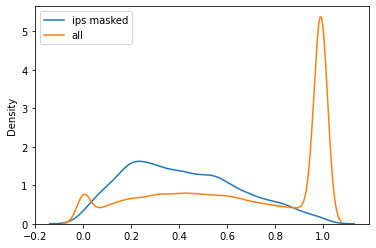

In [21]:
import seaborn as sns   
import matplotlib.pyplot as plt

sns.kdeplot(data[mask],label='ips masked')
sns.kdeplot(data, label='all')
plt.legend()
plt.show()


<AxesSubplot:ylabel='Density'>

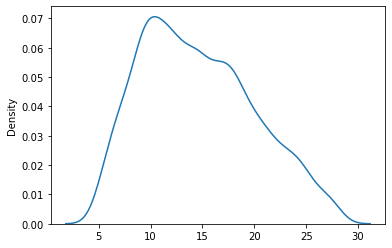

In [22]:
sns.kdeplot(prf_pars['mu'].values[mask],label='ips masked')